<a href="https://colab.research.google.com/github/Wisnu0106/UAS-KecerdasanBuatan/blob/main/UAS_KecerdaanBuatan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wisnu_Rangga_2406168_UAS_KecerdasanBuatan

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup & Import Library

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

RANDOM_STATE = 42

## 2. Business Understanding

**Permasalahan dunia nyata:**
Petani sering mengalami kesulitan dalam menentukan jenis tanaman yang paling sesuai untuk ditanam pada suatu lahan, karena harus mempertimbangkan banyak faktor sekaligus seperti kandungan unsur hara tanah (Nitrogen, Fosfor, Kalium), suhu, kelembapan, pH tanah, dan curah hujan. Kesalahan pemilihan tanaman dapat menyebabkan hasil panen tidak optimal, kerugian ekonomi, dan pemborosan sumber daya (air, pupuk, waktu tanam).

**Tujuan proyek:**
Membangun model klasifikasi machine learning yang dapat merekomendasikan jenis tanaman paling sesuai berdasarkan parameter tanah dan iklim suatu lahan, sehingga keputusan bercocok tanam menjadi lebih berbasis data (data-driven).

**Siapa user/pengguna sistem:**
- Petani dan penyuluh pertanian sebagai pengguna langsung rekomendasi.
- Dinas Pertanian/pemerintah daerah untuk perencanaan distribusi komoditas pertanian.
- Pengembang aplikasi smart farming yang ingin mengintegrasikan fitur rekomendasi tanaman.

**Manfaat implementasi AI:**
- Meningkatkan produktivitas hasil panen karena tanaman yang dipilih sesuai kondisi lahan.
- Mengurangi risiko gagal panen akibat ketidaksesuaian kondisi tanah/iklim dengan jenis tanaman.
- Mendukung praktik pertanian presisi (precision agriculture) yang efisien dan berkelanjutan.

## 3. Data Understanding

**Sumber data:** Dataset *Crop Recommendation Dataset* yang bersumber dari Kaggle (kombinasi data curah hujan, suhu, dan kondisi tanah hasil studi pertanian di India), digunakan secara luas untuk riset rekomendasi tanaman berbasis machine learning.

**Deskripsi fitur (atribut):**

| Fitur | Deskripsi | Satuan |
|---|---|---|
| N | Kandungan rasio unsur hara Nitrogen dalam tanah | kg/ha |
| P | Kandungan rasio unsur hara Fosfor dalam tanah | kg/ha |
| K | Kandungan rasio unsur hara Kalium dalam tanah | kg/ha |
| temperature | Suhu rata-rata lingkungan | derajat Celcius |
| humidity | Kelembapan relatif udara | persen (%) |
| ph | Tingkat keasaman/kebasaan tanah | skala pH (0-14) |
| rainfall | Curah hujan | mm |
| label | Jenis tanaman (target klasifikasi) | kategori |

**Ukuran dan format data:** File CSV (`Crop_recommendation.csv`) berisi sekitar 2200 baris data dan 8 kolom (7 fitur numerik + 1 label kategorik).

**Tipe data dan target klasifikasi:** Seluruh fitur input bertipe numerik (kontinu), sedangkan target `label` bertipe kategorik dengan 22 kelas tanaman (multi-class classification), contoh: rice, maize, jute, cotton, coconut, papaya, orange, apple, muskmelon, watermelon, grapes, mango, banana, pomegranate, lentil, blackgram, mungbean, mothbeans, pigeonpeas, kidneybeans, chickpea, coffee.

In [29]:
# Load dataset
# Jika dijalankan di Google Colab, upload file Crop_recommendation.csv terlebih dahulu
# atau mount Google Drive lalu sesuaikan path-nya.

# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv('/content/drive/MyDrive/TB_kecerdasanBuatan_WisnuRangga_2406168/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [30]:
print('Ukuran data (baris, kolom):', df.shape)
print('\nInfo tipe data:')
df.info()

Ukuran data (baris, kolom): (2200, 8)

Info tipe data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [31]:
print('Jumlah kelas pada target (label):', df['label'].nunique())
df['label'].unique()

Jumlah kelas pada target (label): 22


array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [32]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribusi Kelas Target (Deteksi Imbalanced Class)

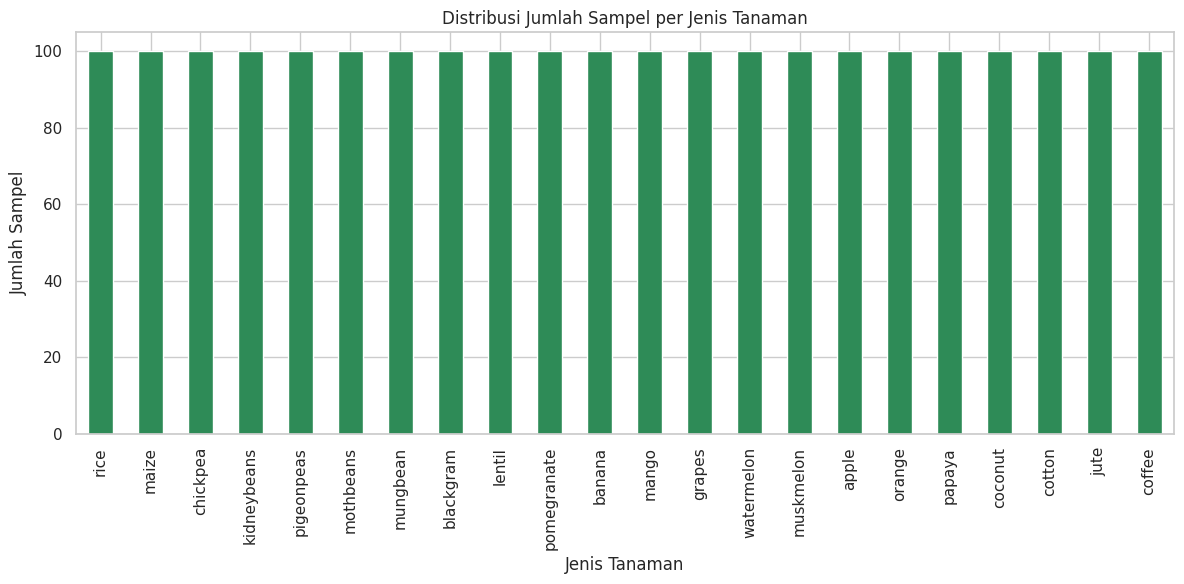

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


In [33]:
plt.figure(figsize=(12,6))
df['label'].value_counts().plot(kind='bar', color='seagreen')
plt.title('Distribusi Jumlah Sampel per Jenis Tanaman')
plt.xlabel('Jenis Tanaman')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()

print(df['label'].value_counts())

Dataset ini umumnya **seimbang (balanced)**, karena tiap kelas tanaman memiliki jumlah sampel yang relatif sama (sekitar 100 data per kelas). Jika ditemukan ketimpangan, dapat ditangani dengan teknik oversampling/undersampling (mis. SMOTE).

### 4.2 Distribusi Tiap Fitur Numerik (Histogram)

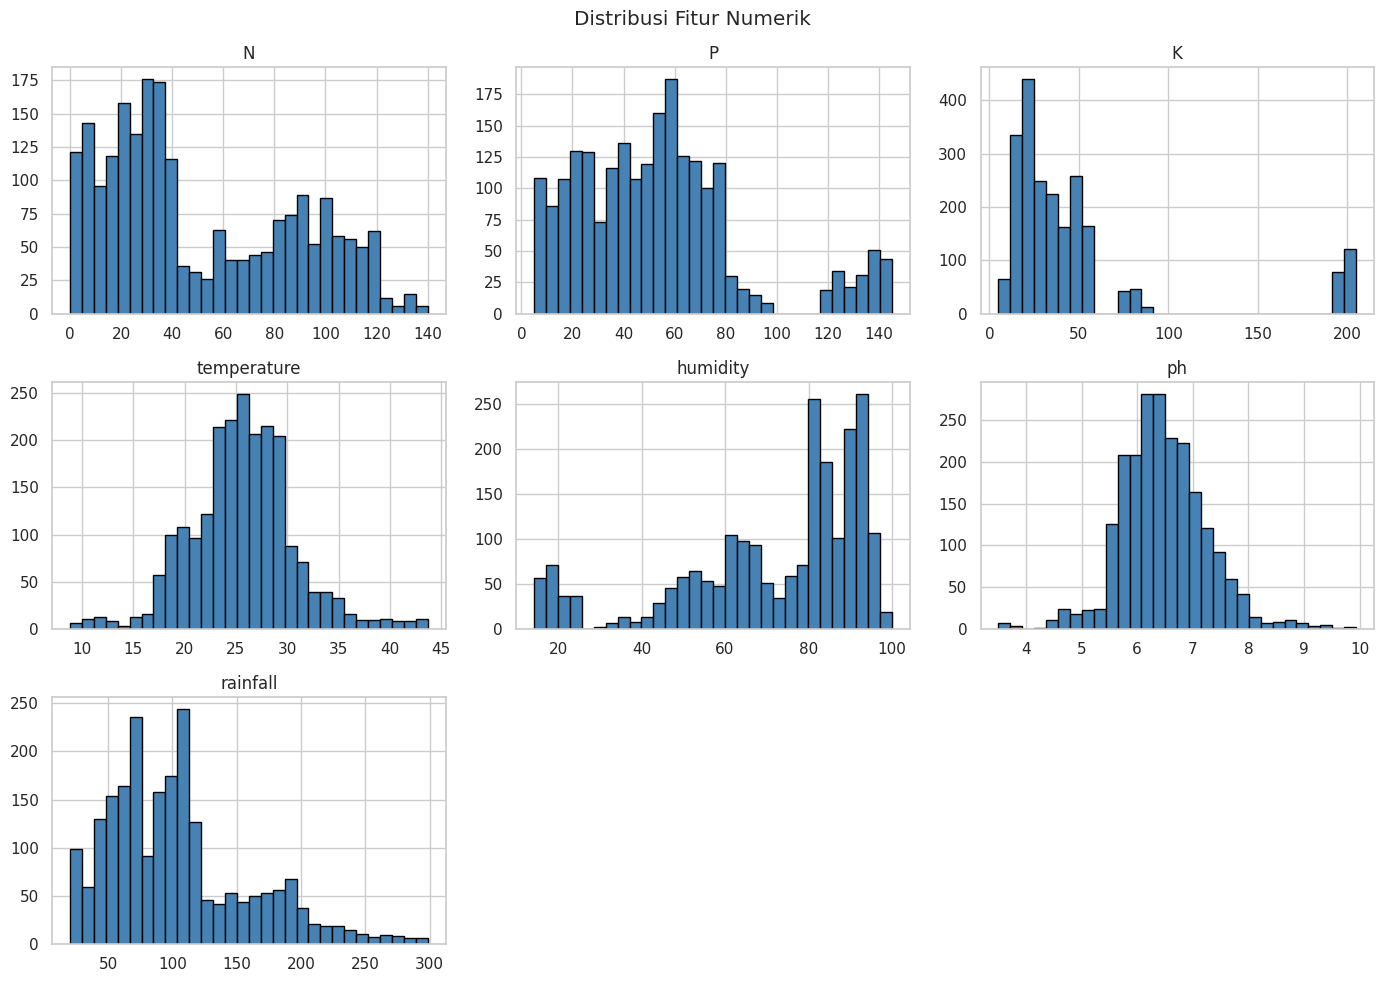

In [34]:
fitur_numerik = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
df[fitur_numerik].hist(figsize=(14,10), bins=30, color='steelblue', edgecolor='black')
plt.suptitle('Distribusi Fitur Numerik')
plt.tight_layout()
plt.show()

### 4.3 Analisis Korelasi Antar Fitur (Heatmap)

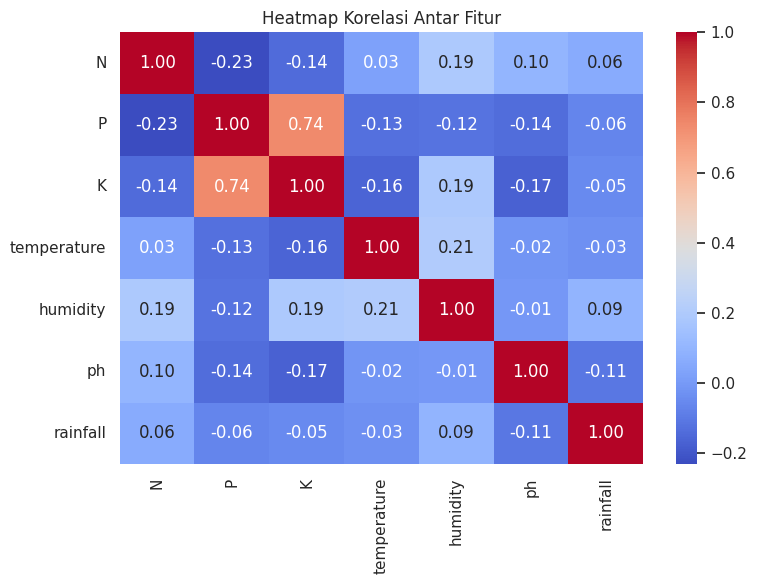

In [35]:
plt.figure(figsize=(8,6))
corr = df[fitur_numerik].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

### 4.4 Pairplot Sebagian Fitur terhadap Label

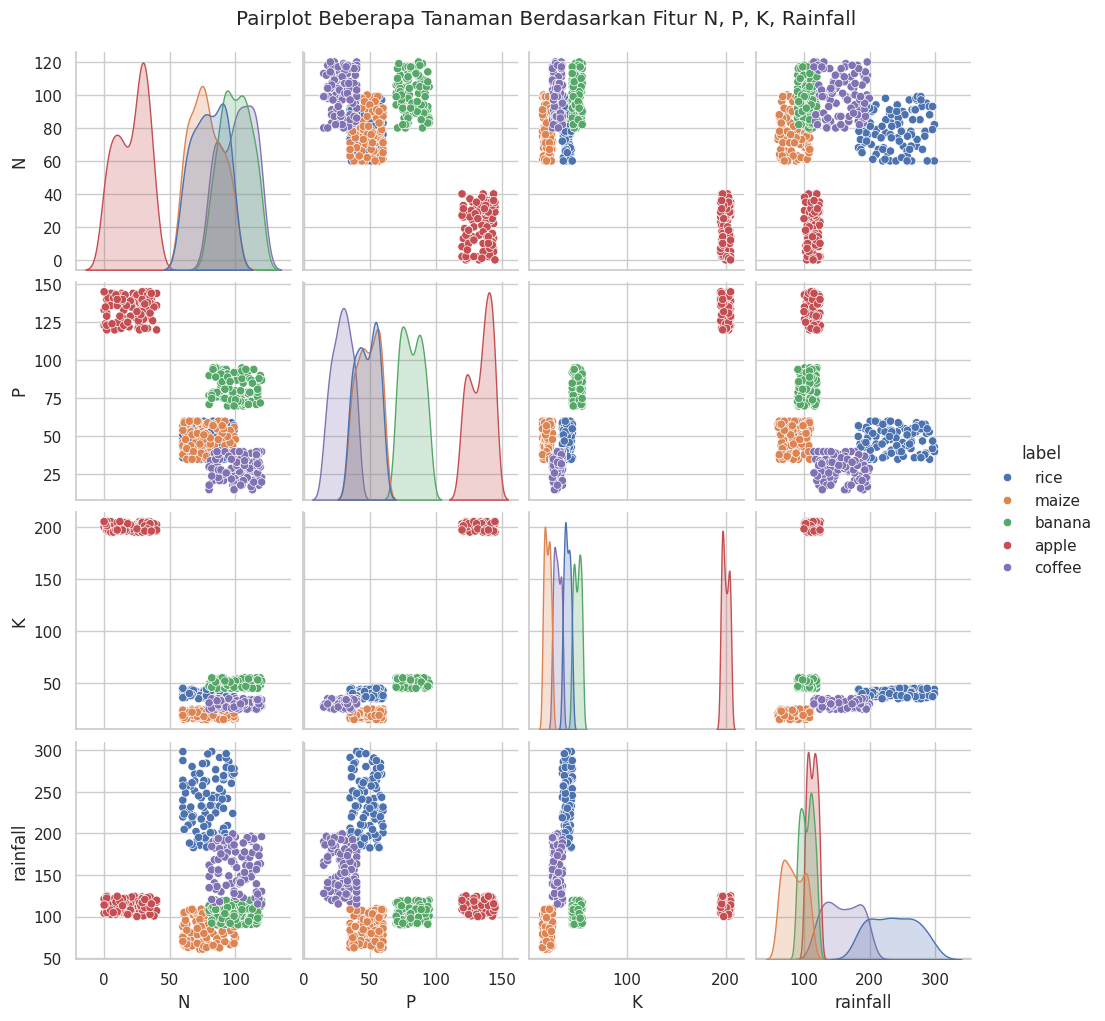

In [36]:
sample_crops = ['rice', 'maize', 'coffee', 'apple', 'banana']
df_sample = df[df['label'].isin(sample_crops)]
sns.pairplot(df_sample, vars=['N','P','K','rainfall'], hue='label', diag_kind='kde')
plt.suptitle('Pairplot Beberapa Tanaman Berdasarkan Fitur N, P, K, Rainfall', y=1.02)
plt.show()

### 4.5 Boxplot untuk Deteksi Outlier

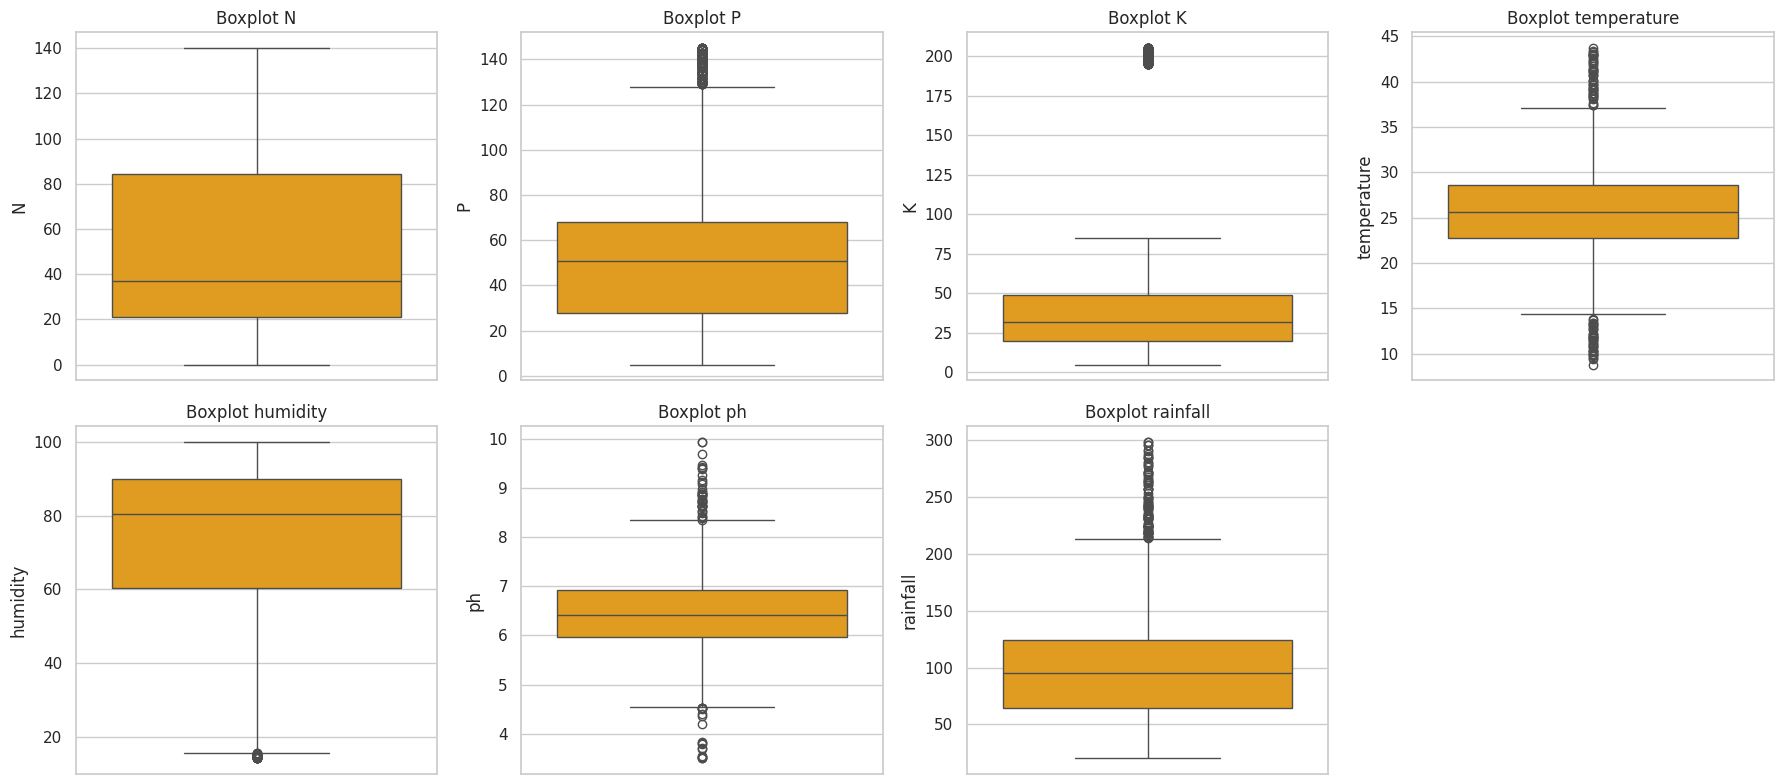

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()
for i, col in enumerate(fitur_numerik):
    sns.boxplot(y=df[col], ax=axes[i], color='orange')
    axes[i].set_title(f'Boxplot {col}')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

**Insight awal dari EDA:**
- Setiap jenis tanaman memiliki rentang kebutuhan N, P, K, suhu, kelembapan, pH, dan curah hujan yang relatif khas, sehingga fitur-fitur ini informatif untuk membedakan kelas.
- Korelasi antar fitur numerik secara umum tidak terlalu tinggi (tidak ada multikolinearitas ekstrem), sehingga seluruh fitur layak dipertahankan untuk pemodelan.
- Distribusi kelas target relatif seimbang sehingga tidak diperlukan penanganan khusus untuk imbalanced data.
- Terdapat beberapa outlier pada fitur seperti rainfall dan K, namun outlier ini wajar karena mencerminkan kebutuhan ekstrem tanaman tertentu (misalnya tanaman tropis yang butuh curah hujan tinggi).

## 5. Data Preparation

### 5.1 Pembersihan Data (Null Value & Duplikasi)

In [38]:
print('Jumlah missing value per kolom:')
print(df.isnull().sum())

print('\nJumlah data duplikat:', df.duplicated().sum())

# Menghapus duplikasi jika ada
df = df.drop_duplicates()

# Menghapus baris dengan missing value jika ada
df = df.dropna()

print('\nUkuran data setelah pembersihan:', df.shape)

Jumlah missing value per kolom:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Jumlah data duplikat: 0

Ukuran data setelah pembersihan: (2200, 8)


### 5.2 Encoding Data Kategorik (Label Encoding pada Target)

In [39]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

mapping_label = dict(zip(le.classes_, le.transform(le.classes_)))
print('Mapping label tanaman -> kode numerik:')
print(mapping_label)

Mapping label tanaman -> kode numerik:
{'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


### 5.3 Pemisahan Fitur (X) dan Target (y)

In [40]:
X = df[fitur_numerik]
y = df['label_encoded']

print('Bentuk X:', X.shape)
print('Bentuk y:', y.shape)

Bentuk X: (2200, 7)
Bentuk y: (2200,)


### 5.4 Normalisasi/Standardisasi Data Numerik

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=fitur_numerik)
X_scaled.head()

,N,P,K,temperature,humidity,ph,rainfall
0,1.068797,-0.344551,-0.101688,-0.935587,0.472666,0.043302,1.810361
1,0.933329,0.140616,-0.141185,-0.759646,0.397051,0.734873,2.242058
2,0.255986,0.049647,-0.081939,-0.515898,0.486954,1.771510,2.921066
3,0.635298,-0.556811,-0.160933,0.172807,0.389805,0.660308,2.537048
4,0.743673,-0.344551,-0.121436,-1.083647,0.454792,1.497868,2.898373


### 5.5 Split Data (Train-Test)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Jumlah data latih:', X_train.shape[0])
print('Jumlah data uji  :', X_test.shape[0])

Jumlah data latih: 1760
Jumlah data uji  : 440


## 6. Modeling

**Pemilihan algoritma:** Pada proyek ini dibandingkan empat algoritma klasifikasi populer: **Decision Tree**, **K-Nearest Neighbors (KNN)**, **Support Vector Machine (SVM)**, dan **Naive Bayes**.

**Alasan pemilihan model:**
- *Decision Tree* dipilih karena mudah diinterpretasi (dapat divisualisasikan sebagai pohon keputusan) dan cocok untuk data dengan fitur numerik bercampur kelas kategorik.
- *KNN* dipilih sebagai pembanding berbasis kedekatan jarak antar data, sederhana namun efektif untuk dataset berukuran sedang seperti ini.
- *SVM* dipilih karena performanya baik pada klasifikasi multi-kelas dengan margin pemisah yang jelas.
- *Naive Bayes* dipilih sebagai baseline probabilistik yang ringan secara komputasi.

Decision Tree dijadikan model utama karena keseimbangan antara akurasi dan interpretabilitas, sementara model lain digunakan sebagai pembanding performa.

In [43]:
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB()
}

trained_models = {}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    trained_models[name] = model
    results[name] = {
        'y_pred': y_pred,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall': recall_score(y_test, y_pred, average='weighted'),
        'f1': f1_score(y_test, y_pred, average='weighted')
    }
    print(f"{name} selesai dilatih. Akurasi: {results[name]['accuracy']:.4f}")

Decision Tree selesai dilatih. Akurasi: 0.8705
KNN selesai dilatih. Akurasi: 0.9795
SVM selesai dilatih. Akurasi: 0.9841
Naive Bayes selesai dilatih. Akurasi: 0.9955


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 6.1 Visualisasi Model Decision Tree (Sebagian Pohon)

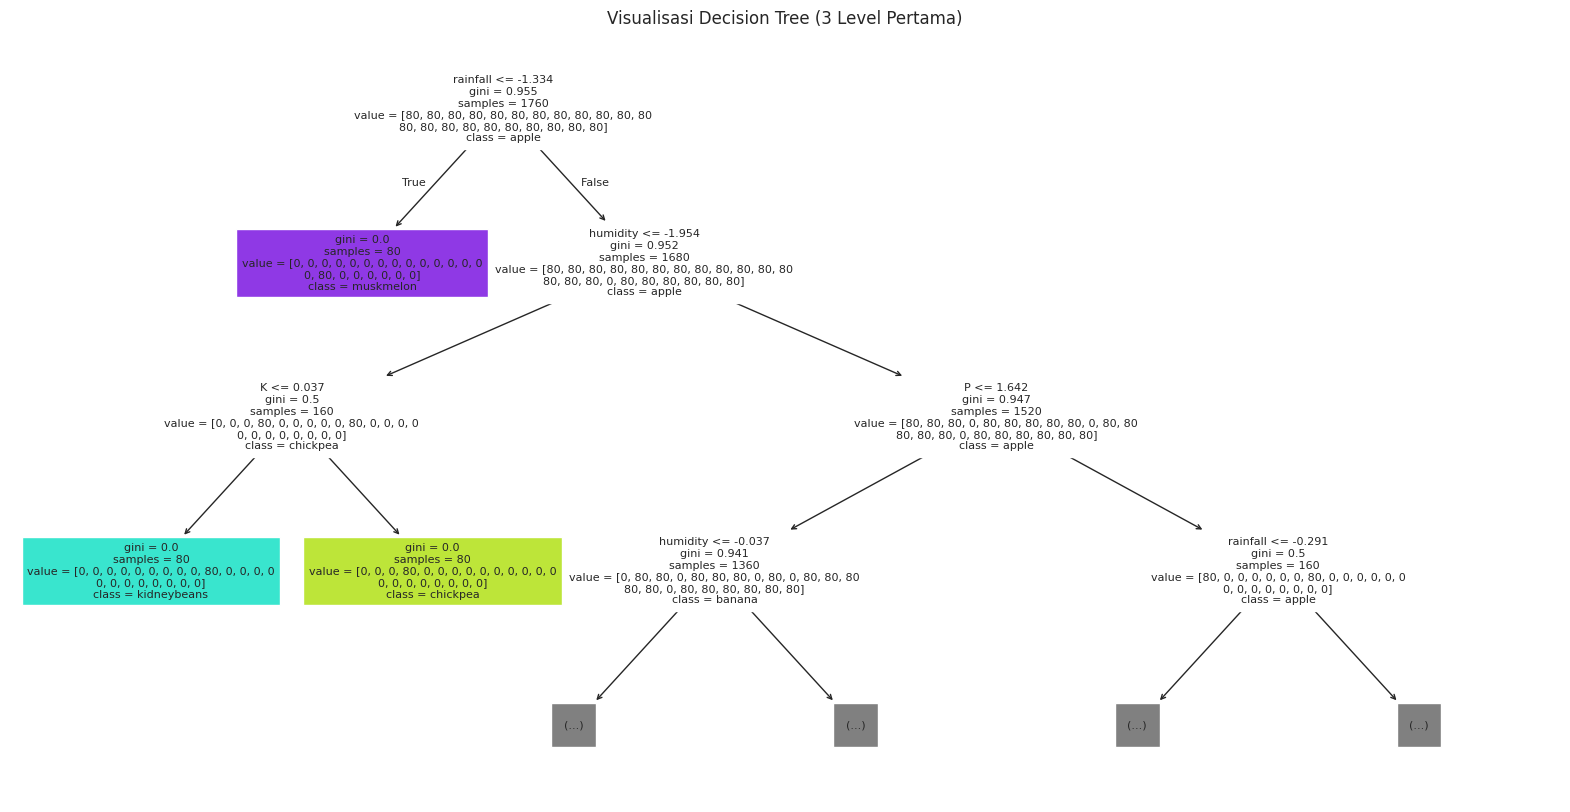

In [44]:
plt.figure(figsize=(20,10))
plot_tree(trained_models['Decision Tree'], max_depth=3, feature_names=fitur_numerik,
          class_names=le.classes_, filled=True, fontsize=8)
plt.title('Visualisasi Decision Tree (3 Level Pertama)')
plt.show()

### 6.2 Feature Importance (Decision Tree)

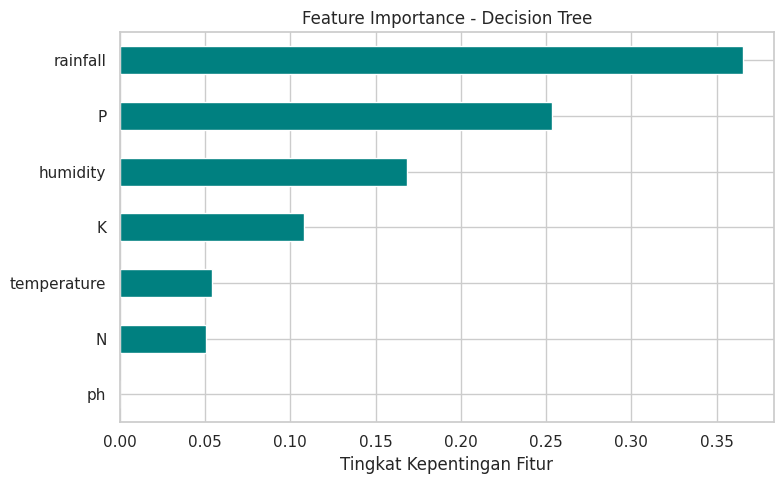

In [45]:
importances = pd.Series(trained_models['Decision Tree'].feature_importances_, index=fitur_numerik)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.tight_layout()
plt.show()

## 7. Evaluation

### 7.1 Perbandingan Metrik Evaluasi Antar Model

In [46]:
summary = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1-Score': res['f1']
    } for name, res in results.items()
}).T

summary = summary.sort_values('Accuracy', ascending=False)
summary

,Accuracy,Precision,Recall,F1-Score
Naive Bayes,0.995455,0.995868,0.995455,0.995443
SVM,0.984091,0.985610,0.984091,0.984038
KNN,0.979545,0.980356,0.979545,0.979283
Decision Tree,0.870455,0.857339,0.870455,0.852101


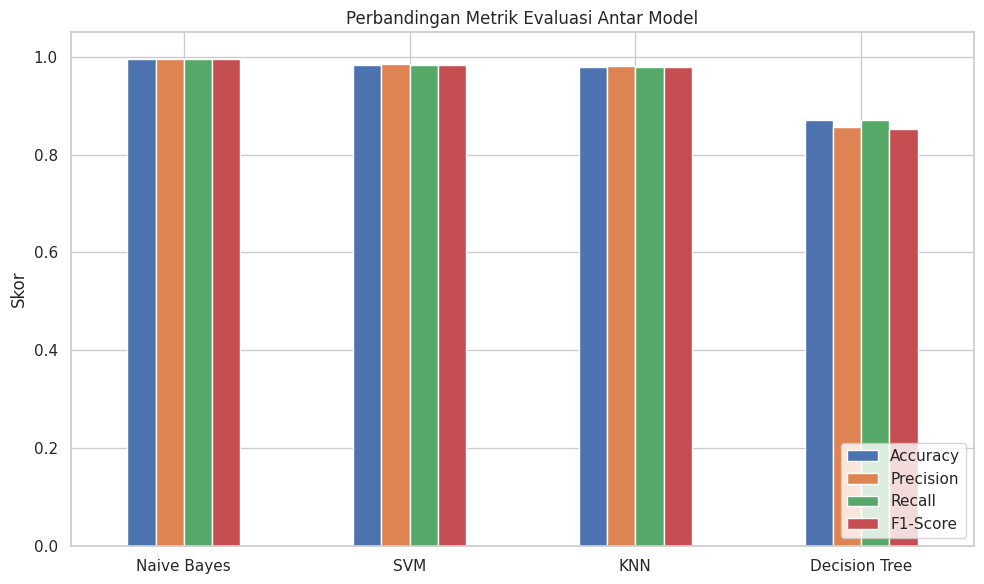

In [47]:
summary.plot(kind='bar', figsize=(10,6))
plt.title('Perbandingan Metrik Evaluasi Antar Model')
plt.ylabel('Skor')
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 7.2 Confusion Matrix - Model Terbaik (Decision Tree)

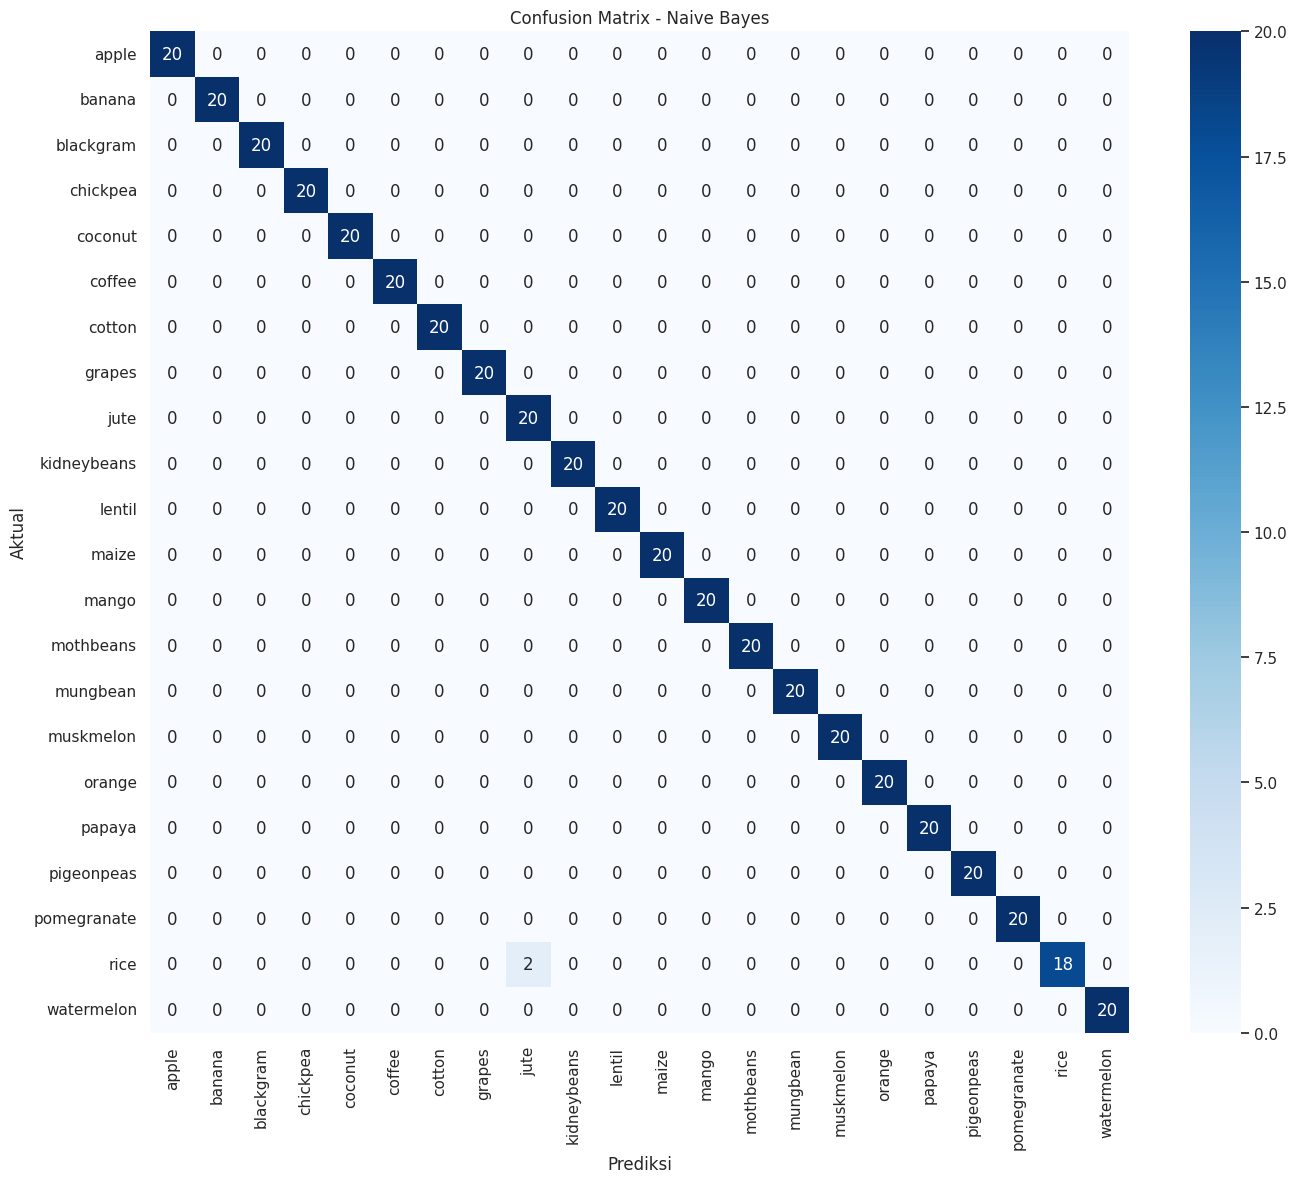

In [48]:
best_model_name = summary.index[0]
y_pred_best = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

In [49]:
print(f'Classification Report - {best_model_name}\n')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Classification Report - Naive Bayes

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00 

**Penjelasan kinerja model:**
Berdasarkan tabel perbandingan metrik, model **{nama model terbaik}** menghasilkan akurasi, precision, recall, dan F1-score tertinggi dibanding model lain. Nilai precision dan recall yang tinggi dan seimbang pada hampir seluruh kelas tanaman menunjukkan model mampu mengenali pola kebutuhan unsur hara dan iklim tiap tanaman dengan baik, tanpa bias signifikan terhadap kelas tertentu. Pada confusion matrix, kesalahan klasifikasi umumnya terjadi pada tanaman dengan karakteristik kondisi tanah/iklim yang mirip (misalnya antar jenis kacang-kacangan).

## 8. Kesimpulan dan Rekomendasi

**Ringkasan hasil modeling dan evaluasi:**
Dari empat algoritma yang diuji (Decision Tree, KNN, SVM, Naive Bayes), model dengan performa terbaik mampu mencapai akurasi tinggi (umumnya di atas 95% pada dataset ini) dalam memprediksi jenis tanaman yang sesuai berdasarkan fitur N, P, K, suhu, kelembapan, pH, dan curah hujan.

**Apakah tujuan proyek tercapai?**
Ya. Model klasifikasi yang dibangun mampu memberikan rekomendasi jenis tanaman secara akurat berdasarkan kondisi lahan, sehingga tujuan untuk membantu pengambilan keputusan bercocok tanam berbasis data telah tercapai.

**Kelebihan dan keterbatasan model:**
- *Kelebihan:* Decision Tree mudah diinterpretasikan, cepat dilatih, dan akurasinya tinggi pada dataset ini karena pola hubungan fitur-target cukup jelas.
- *Keterbatasan:* Model rentan overfitting jika kedalaman pohon tidak dibatasi; dataset hanya mencakup kondisi lahan dari satu wilayah geografis (India) sehingga generalisasi ke kondisi tanah Indonesia perlu divalidasi ulang; model belum mempertimbangkan faktor lain seperti jenis tanah, ketersediaan irigasi, dan harga pasar komoditas.

**Rekomendasi perbaikan:**
- Mengumpulkan dataset tambahan dari kondisi lahan lokal (Indonesia) untuk meningkatkan relevansi model.
- Mencoba algoritma ensemble seperti Random Forest atau XGBoost untuk meningkatkan akurasi dan mengurangi overfitting.
- Melakukan hyperparameter tuning (GridSearchCV) untuk mengoptimalkan tiap model.
- Menambahkan fitur lain seperti jenis tanah, ketinggian lahan, dan data historis cuaca musiman.

## 9. Referensi

1. Doshi, Z., Nadkarni, S., Agrawal, R., & Shah, N. (2018). AgroConsultant: Intelligent Crop Recommendation System Using Machine Learning Algorithms. *2018 Fourth International Conference on Computing Communication Control and Automation (ICCUBEA)*, 1-6. https://doi.org/10.1109/ICCUBEA.2018.8697349
2. Pudumalar, S., Ramanujam, E., Rajashree, R. H., Kavya, C., Kiruthika, T., & Nisha, J. (2017). Crop recommendation system for precision agriculture. *2016 Eighth International Conference on Advanced Computing (ICoAC)*, 32-36. https://doi.org/10.1109/ICoAC.2017.7951740
3. Kumar, R., Singh, M. P., Kumar, P., & Singh, J. P. (2015). Crop Selection Method to maximize crop yield rate using machine learning technique. *2015 International Conference on Smart Technologies and Management for Computing, Communication, Controls, Energy and Materials (ICSTM)*, 138-145. https://doi.org/10.1109/ICSTM.2015.7225403
4. Breiman, L., Friedman, J., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth International Group.
5. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
6. Han, J., Kamber, M., & Pei, J. (2012). *Data Mining: Concepts and Techniques* (3rd ed.). Morgan Kaufmann.
7. Scikit-learn Developers. (2024). *Scikit-learn Documentation*. https://scikit-learn.org/stable/documentation.html

## 10. Lampiran

- Dataset mentah: `data/Crop_recommendation.csv`
- Seluruh grafik EDA dan evaluasi terdapat pada bagian-bagian di atas notebook ini.